In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np

from mad.configs import EARTH_SETTINGS
from mad.objs import ProjectileConfig
from mad.objs import Planet, PlanetConfig
from mad.utils.logger import SourceLogger
from mad.utils.plotters import plot_2D_planet_with_points
import matplotlib.pyplot as plt

logger = SourceLogger()

In [3]:
EARTH_SETTINGS["position"] = [0.0, 0.0]
earth = Planet(PlanetConfig(**EARTH_SETTINGS))

earth

Planet Earth at [0. 0. 0.]
Mass 5.97e+24 kg, Radius 6371.0 km.
Gravity at surface: -9.82 m/s^2
Orbital velocity: 7909.55 m/s
Escape velocity: 11185.79 m/s

In [6]:
projectile_cfg = ProjectileConfig(
    **{
        "mass": 50,
        "ref_radius": 0.,
    }
)

dt = 1
t = 0.0
proj = projectile_cfg.create(position=[earth.radius + 1000, 0.0], velocity=[0, earth.orbital_velocity * 1.2], t=t)

time_scale = [t]
pos, vel = [proj.position.copy()], [proj.velocity.copy()]

while t < 20000:
    proj.integrate(dt, planet=earth)

    time_scale.append(t)
    pos.append(proj.position.copy())
    vel.append(proj.velocity.copy())
    t += dt
    if not proj.active:
        break

logger["Simulation"].info(f" Simulation ended at {t:.2f}")

13:56:23 | INFO     | Simulation   |  Simulation ended at 20000.00


In [7]:
pos = np.asarray(pos)
vel = np.asarray(vel)

posx, posz = pos[:, 0], pos[:, 1]

altitude = np.linalg.norm(pos, axis=1) - earth.radius
velout = np.linalg.norm(vel, axis=1)

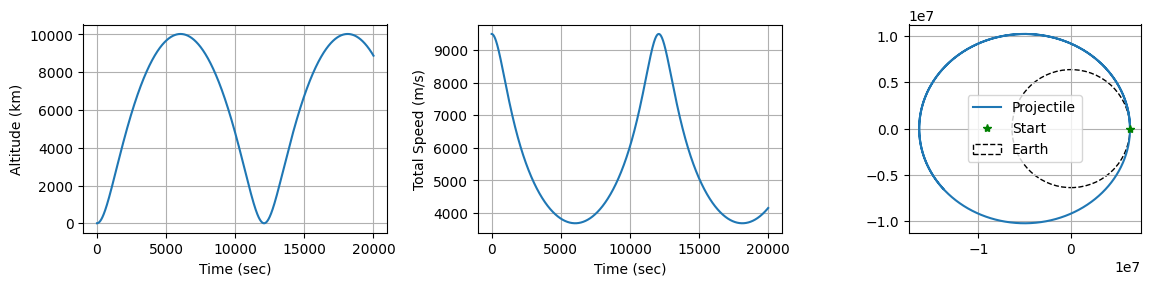

In [8]:
fig, ax = plt.subplots(ncols=3, nrows=1, figsize=(12, 3))
ax.flatten()

ax[0].plot(time_scale, altitude/1000)
ax[0].set_xlabel("Time (sec)")
ax[0].set_ylabel("Altitude (km)")
ax[0].grid()

ax[1].plot(time_scale, velout)
ax[1].set_xlabel("Time (sec)")
ax[1].set_ylabel("Total Speed (m/s)")
ax[1].grid()

ax[2].plot(posx, posz, label="Projectile")
ax[2].plot(posx[0], posz[0], "g*", label="Start")
plot_2D_planet_with_points(planet = earth, ax=ax[2],)

fig.tight_layout(pad=1.2)